In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [81]:
df = pd.read_excel("../data/Main_Data_Bank.xlsx")
print("✅ 数据读取成功，共有行数:", len(df))
print("✅ 列名如下:")
print(df.columns.tolist())

✅ 数据读取成功，共有行数: 37053
✅ 列名如下:
['ID NR (anonymisert dummy)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'Kommune', 'Fylke', 'Tilskudd i USD', 'NY tilskuddskategori', 'Bransje', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'Bankkunde (1/0)', 'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET', 'BANK WALLET I MNOK', 'Har lån i bank (alle banker)', 'Kundelønnsomhet Lønnsomhet Bankr i Norge']


In [82]:
# 去除列名空格与特殊字符
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^0-9A-Za-z_]", "", regex=True)

# 删除明显无关列
drop_cols = ['ID_NR_anonymisert_dummy','Bankkunde_10','SUM_UTLN','SUM_RAMME','SUM_INNSKUDD', 'BANK_WALLET', 'BANK_WALLET_I_MNOK']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# 替换 “ja/nei” 为 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0})

print(df)
# 将可能的目标列转换为数值
target_col = 'Har_ln_i_bank_alle_banker'
df[target_col] = df[target_col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0}).astype(float)

# 删除目标缺失值
df = df.dropna(subset=[target_col])

# 输出基本信息
print(f"目标变量 '{target_col}' 值分布：")
print(df[target_col].value_counts())


       Mislighold_30_og_90_dg_janei Misligholdstype      Kommune      Fylke  \
0                               1.0        30-90 dg  NORDRE LAND  Innlandet   
1                               1.0        30-90 dg    BJERKREIM   Rogaland   
2                               1.0        30-90 dg          SEL  Innlandet   
3                               1.0        30-90 dg       ØRLAND  Trøndelag   
4                               1.0        30-90 dg        GRANE   Nordland   
...                             ...             ...          ...        ...   
37048                           NaN             NaN         TIME   Rogaland   
37049                           NaN             NaN      ORKLAND  Trøndelag   
37050                           NaN             NaN       SILJAN   Telemark   
37051                           NaN             NaN       LÆRDAL   Vestland   
37052                           NaN             NaN        SVEIO   Vestland   

       Tilskudd_i_USD NY_tilskuddskategori  \
0    

/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_72096/621733864.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0})


In [83]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()[target_col].sort_values(ascending=False)
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
print("\n与贷款目标相关度最高的前15个特征：")
print(corr.head(15))


与贷款目标相关度最高的前15个特征：
Har_ln_i_bank_alle_banker    1.000000
Produkiv_skog                0.065536
Storfe                       0.061175
Gress                        0.059014
Ingen                        0.053979
Tilskudd_i_USD               0.051451
Korn                         0.049788
Gris                         0.048269
Gris_dyr                     0.046343
Kompleks_produksjon_10       0.045241
ENG_janei                    0.043091
Gress_dekar                  0.037903
Storfe_dyr                   0.037052
NY_KOMMUNESCORE              0.031992
Annet                        0.031193
Name: Har_ln_i_bank_alle_banker, dtype: float64


/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_72096/2644775597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.head(15).values, y=corr.head(15).index, palette="viridis")


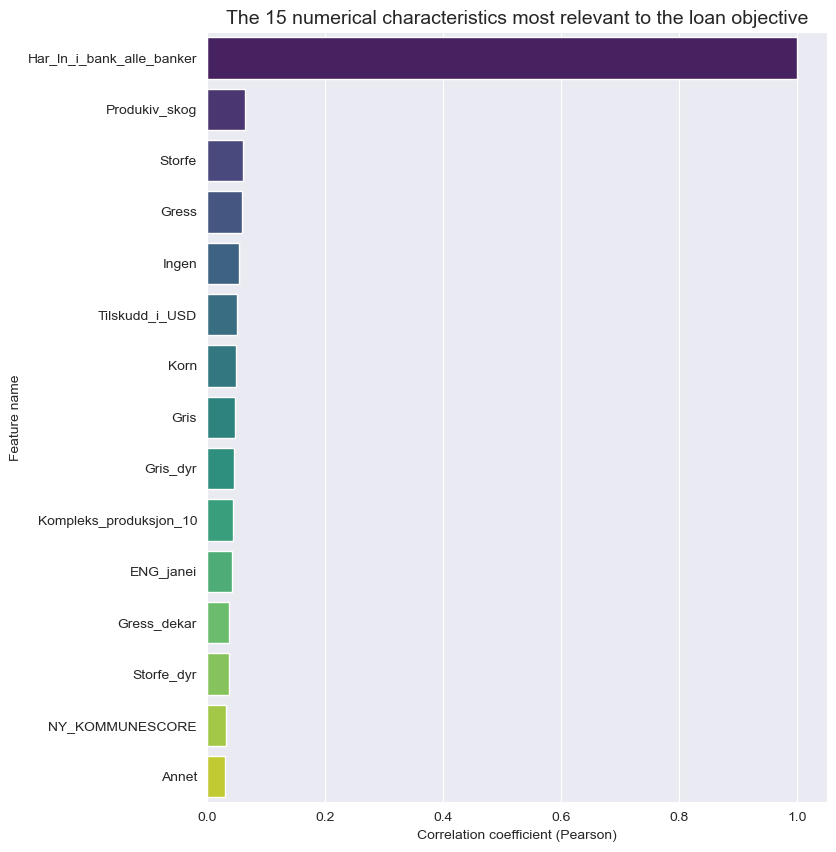

In [84]:
plt.figure(figsize=(8, 10))
sns.barplot(x=corr.head(15).values, y=corr.head(15).index, palette="viridis")
plt.title("The 15 numerical characteristics most relevant to the loan objective", fontsize=14)
plt.xlabel("Correlation coefficient (Pearson)")
plt.ylabel("Feature name")
plt.show()

In [85]:
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != target_col]

for col in cat_cols:
    print(f"\n▶ 类别特征 {col} 与贷款的平均比例：")
    print(df.groupby(col)[target_col].mean().sort_values(ascending=False).head(10))



▶ 类别特征 Misligholdstype 与贷款的平均比例：
Misligholdstype
30-90 dg    0.666667
90 dg+      0.642857
Name: Har_ln_i_bank_alle_banker, dtype: float64

▶ 类别特征 Kommune 与贷款的平均比例：
Kommune
MELHUS        0.806723
RINDAL        0.784615
HAMMERFEST    0.750000
SKAUN         0.748092
ENEBAKK       0.736111
BYKLE         0.727273
INDERØY       0.706186
BJERKREIM     0.705202
ÅSERAL        0.704545
OVERHALLA     0.704348
Name: Har_ln_i_bank_alle_banker, dtype: float64

▶ 类别特征 Fylke 与贷款的平均比例：
Fylke
Trøndelag          0.632328
Møre Og Romsdal    0.554783
Østfold            0.549331
Rogaland           0.539623
Vestfold           0.538782
Akershus           0.525012
Vestland           0.517306
Telemark           0.496448
Buskerud           0.474640
Agder              0.461622
Name: Har_ln_i_bank_alle_banker, dtype: float64

▶ 类别特征 NY_tilskuddskategori 与贷款的平均比例：
NY_tilskuddskategori
L     0.561848
M     0.550023
S     0.516699
XS    0.450074
Name: Har_ln_i_bank_alle_banker, dtype: float64

▶ 类别特征 Bransje 与贷款的平均

In [86]:
important_features = corr[abs(corr) > 0.05].index.tolist()
important_features.remove(target_col)
print("\n📌 建议用于建模的关键特征：")
print(important_features)


📌 建议用于建模的关键特征：
['Produkiv_skog', 'Storfe', 'Gress', 'Ingen', 'Tilskudd_i_USD', 'Bier']



✅ 分类报告（Classification Report）:
              precision    recall  f1-score   support

         0.0       0.59      0.52      0.55      3592
         1.0       0.59      0.66      0.63      3819

    accuracy                           0.59      7411
   macro avg       0.59      0.59      0.59      7411
weighted avg       0.59      0.59      0.59      7411


✅ 混淆矩阵（Confusion Matrix）:
[[1868 1724]
 [1290 2529]]

📈 对贷款预测影响最大的前15个特征：
                                                Feature  Coefficient
532   Bransje_Engroshandel med maskiner og utstyr ti...     1.390131
1565                            PRODUKSJON_Grønt, Potet     1.356228
147                                  Kommune_HAMMERFEST     1.310265
427                 Bransje_Andre post- og budtjenester     1.262017
1080                     PRODUKSJON_Egg, Korn, Salg fôr     1.169300
1621                               PRODUKSJON_Korn, Sau     1.143830
1541                          PRODUKSJON_Gris, Salg fôr     1.125455
571   Bransje_

/var/folders/xv/d84s8vcj4mndphc98_7b_m2r0000gn/T/ipykernel_72096/2082786848.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=coef_df.head(15)['Feature'], x=coef_df.head(15)['Coefficient'], palette='coolwarm')


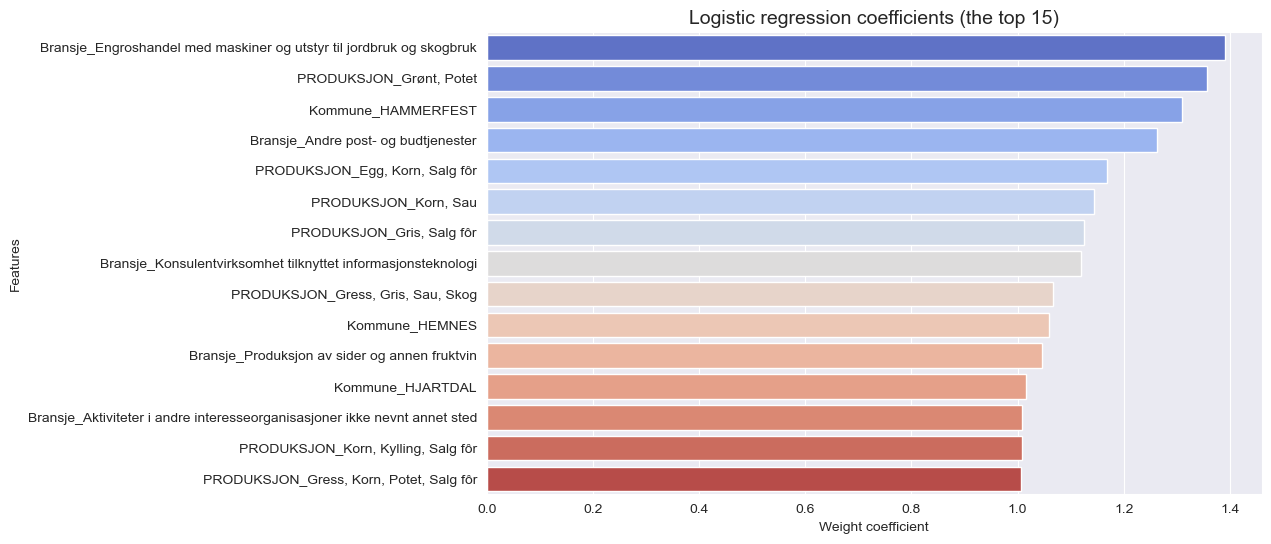

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 分离类别和数值列

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded[target_col] = df_encoded[target_col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0}).astype(float)
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]
X = X.fillna(0)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\n✅ 分类报告（Classification Report）:")
print(classification_report(y_test, y_pred))
print("\n✅ 混淆矩阵（Confusion Matrix）:")
print(confusion_matrix(y_test, y_pred))
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n📈 对贷款预测影响最大的前15个特征：")
print(coef_df.head(15))

plt.figure(figsize=(10,6))
sns.barplot(y=coef_df.head(15)['Feature'], x=coef_df.head(15)['Coefficient'], palette='coolwarm')
plt.title("Logistic regression coefficients (the top 15)", fontsize=14)
plt.xlabel("Weight coefficient")
plt.ylabel("Features")
plt.show()

